Registros limpios procesados con éxito: 1,029,407

Distribución y prevalencia epidemiológica del nuevo target binario:
y_binario
0    0.996103
1    0.003897
Name: proportion, dtype: float64

Partición Temporal -> Train: 438,021 | Val: 63,216 | Test: 528,170
Prevalencia artificial establecida en Train: 6.2500%

Optimización del clasificador completada sobre la muestra asimétrica.
Frontera de decisión óptima calculada (Max F1-Score): tau = 0.007614

PR-AUC Calibrado Final (Bloque OOD): 0.0056

=== REPORTE DE TRIAJE CLÍNICO BIFÁSICO (TEST SET - OPTIMIZADO) ===
              precision    recall  f1-score   support

    No Grave       1.00      0.97      0.98    526417
       Grave       0.01      0.11      0.02      1753

    accuracy                           0.97    528170
   macro avg       0.51      0.54      0.50    528170
weighted avg       0.99      0.97      0.98    528170



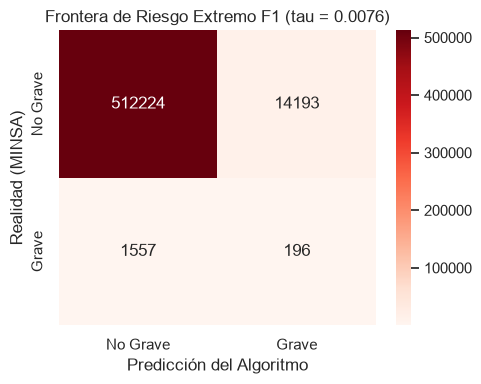

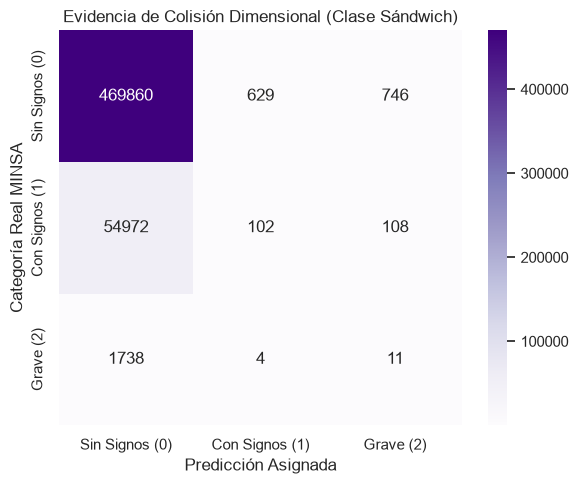


Extrayendo la lógica interna del algoritmo (Feature Importance)...


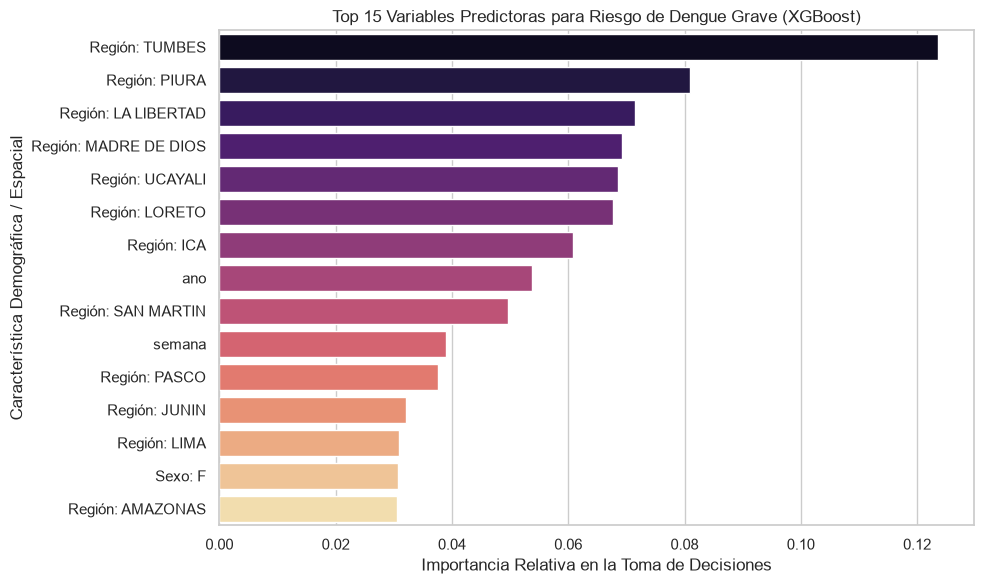

In [1]:
# ==============================================================================
# PIPELINE UNIFICADO Y CALIBRADO DE CLASIFICACIÓN (02_Clasificacion.ipynb)
# ==============================================================================
import sys
sys.path.append('../src')  # Inyección del path para acceder a los módulos de src

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import (roc_curve, confusion_matrix, classification_report, 
                             precision_recall_curve, auc)

# Configuración estética base
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

# ------------------------------------------------------------------------------
# FASE 0: CARGA Y PREPROCESAMIENTO ESTRUCTURAL (MÓDULO DATA.PY)
# ------------------------------------------------------------------------------
from data import cargar_crudo, normalizar_edad, ORDEN_SEVERIDAD

# Carga de la base de datos nacional del MINSA (2000-2024)
df_raw = cargar_crudo()
df_processed = normalizar_edad(df_raw)

# Conversión estricta de tipos temporales numéricos
for col in ['ano', 'semana']:
    df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

# Mapeo ordinal original de severidad clínica {0: Sin signos, 1: Con signos, 2: Grave}
df_processed['severidad'] = df_processed['enfermedad'].map(ORDEN_SEVERIDAD)

# Filtros de consistencia y depuración de registros nulos
df_processed = df_processed[df_processed['sexo'].isin(['M', 'F'])]
df_processed = df_processed[df_processed['edad_anios'].between(0, 110)]
df_processed = df_processed.dropna(subset=['severidad', 'edad_anios', 'ano', 'semana'])
df_processed['severidad'] = df_processed['severidad'].astype(int)

print(f"Registros limpios procesados con éxito: {df_processed.shape[0]:,}")

# ==============================================================================
# PASO 1.1: REFORMULACIÓN DEL TARGET (TRIAJE BINARIO DE RIESGO EXTREMO)
# ==============================================================================
# Agrupamos las clases 0 y 1 en 'No Grave' (0) y aislamos la clase 2 como 'Grave' (1)
df_processed['y_binario'] = (df_processed['severidad'] == 2).astype(int)
print("\nDistribución y prevalencia epidemiológica del nuevo target binario:")
print(df_processed['y_binario'].value_counts(normalize=True))

# ==============================================================================
# PASO 1.2: PARTICIÓN TEMPORAL RÍGIDA POR BLOQUES CRONOLÓGICOS (EVITAR LEAKAGE)
# ==============================================================================
df_ordenado = df_processed.sort_values(by=["ano", "semana"]).reset_index(drop=True)

df_train_raw = df_ordenado[df_ordenado['ano'] <= 2021].reset_index(drop=True)
df_val       = df_ordenado[df_ordenado['ano'] == 2022].reset_index(drop=True)
df_test      = df_ordenado[df_ordenado['ano'].isin([2023, 2024])].reset_index(drop=True)

print(f"\nPartición Temporal -> Train: {df_train_raw.shape[0]:,} | Val: {df_val.shape[0]:,} | Test: {df_test.shape[0]:,}")

# ==============================================================================
# PASO 1.3: DISEÑO DE CASOS Y CONTROLES ASIMÉTRICO (SÓLO EN EL CONJUNTO TRAIN)
# ==============================================================================
df_train_pos = df_train_raw[df_train_raw['y_binario'] == 1]
df_train_neg = df_train_raw[df_train_raw['y_binario'] == 0]

n_graves_train = len(df_train_pos)
n_controles_needed = n_graves_train * 15  # Relación fija de casos y controles 1:15

df_train_neg_sub = df_train_neg.sample(n=min(n_controles_needed, len(df_train_neg)), random_state=RANDOM_STATE)
df_train_final = pd.concat([df_train_pos, df_train_neg_sub]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Verificación de la prevalencia artificial de entrenamiento (6.25%)
prevalencia_train = df_train_final['y_binario'].mean()
print(f"Prevalencia artificial establecida en Train: {prevalencia_train:.4%}")

# Definición de vectores de características independientes
FEATURES = ['edad_anios', 'sexo', 'departamento', 'semana', 'ano']
X_train, y_train = df_train_final[FEATURES], df_train_final['y_binario']
X_val, y_val     = df_val[FEATURES], df_val['y_binario']
X_test, y_test   = df_test[FEATURES], df_test['y_binario']

# ==============================================================================
# PASO 1.4: CONSTRUCCIÓN DEL PIPELINE DE ENTRENAMIENTO
# ==============================================================================
preprocesador = ColumnTransformer([
    ('num', StandardScaler(), ['edad_anios', 'semana', 'ano']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['sexo', 'departamento'])
])

pipeline_modelo = Pipeline([
    ('prep', preprocesador),
    ('clf', XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, eval_metric='logloss'))
])
pipeline_modelo.fit(X_train, y_train)
print("\nOptimización del clasificador completada sobre la muestra asimétrica.")

# ==============================================================================
# PASO 1.5: AJUSTE DE PRIOR SHIFT MEDIANTE LA FÓRMULA DE SAERENS (2001)
# ==============================================================================
def corregir_probabilidades_bayes(p_train, prev_real, prev_train):
    """Restauración bayesiana exacta de probabilidades poblacionales reales."""
    num = p_train * (prev_real / prev_train)
    den = num + ((1 - p_train) * ((1 - prev_real) / (1 - prev_train)))
    return num / (den + 1e-12)

# Extracción de estimaciones probabilísticas crudas
proba_val_raw = pipeline_modelo.predict_proba(X_val)[:, 1]
proba_test_raw = pipeline_modelo.predict_proba(X_test)[:, 1]

# Tasas reales específicas observadas por bloque cronológico
prev_real_val = y_val.mean()
prev_real_test = y_test.mean()

# Calibración matemática de las salidas
proba_val_calibrada = corregir_probabilidades_bayes(proba_val_raw, prev_real_val, prevalencia_train)
proba_test_calibrada = corregir_probabilidades_bayes(proba_test_raw, prev_real_test, prevalencia_train)

# ==============================================================================
# PASO 1.6: OPTIMIZACIÓN DE FRONTERA POR F1-SCORE Y EVALUACIÓN FINAL OOD
# ==============================================================================
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_val, proba_val_calibrada)

# Calcular F1-Score para cada umbral (evitando división por cero)
f1_scores = np.divide(
    2 * (precision_curve * recall_curve),
    (precision_curve + recall_curve),
    out=np.zeros_like(precision_curve),
    where=(precision_curve + recall_curve) != 0
)

# Encontrar el umbral que maximiza F1 (equilibrio entre precisión y recall)
idx_optimo_f1 = np.argmax(f1_scores)
tau_optimo = thresholds_pr[idx_optimo_f1]
print(f"Frontera de decisión óptima calculada (Max F1-Score): tau = {tau_optimo:.6f}")

# Binarización operativa final sobre el bloque histórico del ciclón Yaku (2023-2024)
y_pred_final = (proba_test_calibrada >= tau_optimo).astype(int)
pr_auc = auc(recall_curve, precision_curve)

print(f"\nPR-AUC Calibrado Final (Bloque OOD): {pr_auc:.4f}")
print("\n=== REPORTE DE TRIAJE CLÍNICO BIFÁSICO (TEST SET - OPTIMIZADO) ===")
print(classification_report(y_test, y_pred_final, target_names=['No Grave', 'Grave']))

# Generación visual de la matriz de confusión calibrada
cm_binaria = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_binaria, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Grave', 'Grave'], yticklabels=['No Grave', 'Grave'])
plt.title(f'Frontera de Riesgo Extremo F1 (tau = {tau_optimo:.4f})')
plt.ylabel('Realidad (MINSA)')
plt.xlabel('Predicción del Algoritmo')
plt.tight_layout()
plt.show()

# ==============================================================================
# PASO 1.7: EVIDENCIA EMPÍRICA DE LA COLISIÓN DE LA CLASE SÁNDWICH
# ==============================================================================
pipeline_multiclase = Pipeline([
    ('prep', preprocesador),
    ('clf', XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, eval_metric='mlogloss'))
])
pipeline_multiclase.fit(X_train, df_train_final['severidad'])
y_pred_multi = pipeline_multiclase.predict(X_test)
cm_multi = confusion_matrix(df_test['severidad'], y_pred_multi)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Sin Signos (0)', 'Con Signos (1)', 'Grave (2)'],
            yticklabels=['Sin Signos (0)', 'Con Signos (1)', 'Grave (2)'])
plt.title('Evidencia de Colisión Dimensional (Clase Sándwich)')
plt.ylabel('Categoría Real MINSA')
plt.xlabel('Predicción Asignada')
plt.tight_layout()
plt.show()

# ==============================================================================
# PASO 1.8: EXTRACCIÓN Y VISUALIZACIÓN DE IMPORTANCIA DE VARIABLES (NUEVO)
# ==============================================================================
print("\nExtrayendo la lógica interna del algoritmo (Feature Importance)...")

# Extraer nombres de las columnas transformadas
cat_encoder = preprocesador.named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(['sexo', 'departamento'])
num_features = ['edad_anios', 'semana', 'ano']
all_features = np.concatenate([num_features, cat_features])

# Extraer los pesos (importancia) del modelo XGBoost binario
importancias = pipeline_modelo.named_steps['clf'].feature_importances_

# Crear un DataFrame estructurado y limpiar nombres
df_importancias = pd.DataFrame({
    'Variable': all_features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

df_importancias['Variable'] = df_importancias['Variable'].str.replace('departamento_', 'Región: ')
df_importancias['Variable'] = df_importancias['Variable'].str.replace('sexo_', 'Sexo: ')

# Graficar el Top 15 de variables más determinantes
plt.figure(figsize=(10, 6))
# Se añade hue='Variable' y legend=False para cumplir con la nueva versión de Seaborn
sns.barplot(data=df_importancias.head(15), x='Importancia', y='Variable', hue='Variable', palette='magma', legend=False)
plt.title('Top 15 Variables Predictoras para Riesgo de Dengue Grave (XGBoost)')
plt.xlabel('Importancia Relativa en la Toma de Decisiones')
plt.ylabel('Característica Demográfica / Espacial')
plt.tight_layout()
plt.show()